# Enriched Music Charts Analysis



**Week:** 2026-W25 | **Analysis Date:** 2026-06-15


## 1. Introduction

This week’s chart report is a vibrant snapshot of global music consumption, drawn from 100 songs across 18 countries and 14 genres—a true map of the world’s listening habits. With over 1.3 billion views and 216 million likes, the numbers alone hint at a landscape of intense engagement, where each track averages 13 million views and more than 2 million likes. But the real story lies in the patterns: which countries are driving the biggest viral waves, how different genres compete for attention, and whether collaborations actually amplify performance. Whether you’re tracking regional breakout hits or analyzing why certain artists dominate the like-to-view ratio, this report unpacks the trends shaping the charts. Dive in to see where the week’s biggest spikes are hiding and what that means for the next wave of music.

## 2. Setup and Data Loading

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import sqlite3
import os
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for inline display in notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Reds")

YT_RED = '#FF0000'
YT_RED_DARK = '#CC0000'
YT_BG = '#FFFFFF'
YT_SURFACE = '#F9F9F9'
YT_TEXT = '#0F0F0F'
YT_GRAY = '#606060'
YT_GRID = '#E5E5E5'

def format_number(x):
    if pd.isna(x): return x
    if x >= 1_000_000_000: return f"{x/1_000_000_000:.1f}B"
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return f"{x:,.0f}"

# Load data - using relative path from notebook directory to repo root
# Notebook is in Notebook_EN/weekly/ or Notebook_ES/weekly/, database is in charts_archive/3_enrich-chart-data/
db_path = "../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W25_enriched.db"
print(f"Loading data from: {db_path}")
conn = sqlite3.connect(db_path)

cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print(f"Tables found: {[t[0] for t in tables]}")

if not tables:
    raise ValueError(f"No tables found in database: {db_path}")

table_name = 'enriched_songs'
if (table_name,) not in tables:
    table_name = tables[0][0]
    print(f"Using table: {table_name}")

df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
conn.close()

df['upload_date'] = pd.to_datetime(df['upload_date'], errors='coerce')
df['upload_quarter'] = df['upload_date'].dt.quarter
df['engagement'] = np.where(df['views'] > 0, (df['likes'] / df['views'] * 100).round(2), 0.0)

print(f"Loaded {len(df)} songs, {df.shape[1]} columns")
df.head()


Loading data from: ../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W25_enriched.db
Tables found: ['enriched_songs']
Loaded 100 songs, 28 columns


,rank,id,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,237,Shakira & Burna Boy,Dai Dai,4,53942114,https://www.youtube.com/watch?v=fcnDmrtj6Sk,241,4:01,2026-05-23,...,0,2,1,Colombia,Pop,2/2,,2026-06-15 18:21:34,2,6.24
1,2,33,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,Golden,51,33724083,https://www.youtube.com/watch?v=yebNIHKAC4A,199,3:19,2025-06-23,...,0,5,0,South Korea,K-Pop/K-Rock,5/5,,2026-06-15 18:21:34,2,20.89
2,3,81,Shashwat Sachdev & Madhubanti Bagchi & Jasmine...,Shararat,26,33214368,https://www.youtube.com/watch?v=YyepU5ztLf4,229,3:49,2025-12-09,...,0,3,0,India,Indian Pop,3/3,,2026-06-15 18:21:34,4,7.78
3,4,188,Shakira,Waka Waka (This Time for Africa) (feat. Freshl...,52,28583839,https://www.youtube.com/watch?v=pRpeEdMmmQ0,211,3:31,2010-06-04,...,0,1,1,Colombia,Pop,1/1,,2026-06-15 18:21:34,2,89.79
4,5,17,Banjaare,Bairan,14,27306257,https://www.youtube.com/watch?v=oafxkMv4xnc,151,2:31,2026-02-13,...,0,1,0,India,Indian Pop,1/1,,2026-06-15 18:21:34,1,7.53


## 3. Data Preview

In [2]:
df.head()

,rank,id,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,237,Shakira & Burna Boy,Dai Dai,4,53942114,https://www.youtube.com/watch?v=fcnDmrtj6Sk,241,4:01,2026-05-23,...,0,2,1,Colombia,Pop,2/2,,2026-06-15 18:21:34,2,6.24
1,2,33,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,Golden,51,33724083,https://www.youtube.com/watch?v=yebNIHKAC4A,199,3:19,2025-06-23,...,0,5,0,South Korea,K-Pop/K-Rock,5/5,,2026-06-15 18:21:34,2,20.89
2,3,81,Shashwat Sachdev & Madhubanti Bagchi & Jasmine...,Shararat,26,33214368,https://www.youtube.com/watch?v=YyepU5ztLf4,229,3:49,2025-12-09,...,0,3,0,India,Indian Pop,3/3,,2026-06-15 18:21:34,4,7.78
3,4,188,Shakira,Waka Waka (This Time for Africa) (feat. Freshl...,52,28583839,https://www.youtube.com/watch?v=pRpeEdMmmQ0,211,3:31,2010-06-04,...,0,1,1,Colombia,Pop,1/1,,2026-06-15 18:21:34,2,89.79
4,5,17,Banjaare,Bairan,14,27306257,https://www.youtube.com/watch?v=oafxkMv4xnc,151,2:31,2026-02-13,...,0,1,0,India,Indian Pop,1/1,,2026-06-15 18:21:34,1,7.53


## 4. General Statistics

In [3]:

stats = pd.DataFrame({
    'Total Songs': [100],
    'Unique Countries': [18],
    'Unique Genres': [14],
    'Total Views': [1311975673],
    'Total Likes': [216175695],
    'Total Comments': [10195221],
    'Avg Views': [13119757],
    'Avg Likes': [2161757]
})

print("GENERAL STATISTICS")
display(stats)


GENERAL STATISTICS


,Total Songs,Unique Countries,Unique Genres,Total Views,Total Likes,Total Comments,Avg Views,Avg Likes
0,100,18,14,1311975673,216175695,10195221,13119757,2161757


The dataset reveals strong global reach, with 100 songs spanning 18 countries and 14 genres, indicating a highly diverse and cross-cultural music landscape. This breadth suggests that artists are successfully tapping into multiple regional and stylistic markets, likely leveraging streaming platforms to bypass traditional geographic barriers. Engagement is robust, with an average of 13.1 million views and 2.2 million likes per song, translating to a 16.5% like-to-view ratio—well above typical industry benchmarks. Such high relative engagement signals deep audience-artist connection and active fan loyalty, not passive consumption. Overall, the data reflects a market where niche genres and international acts can achieve mainstream-scale traction, driven by algorithm-driven discovery and highly engaged, global fanbases.

## 5. Country Analysis

### 5.1. Continent Distribution


CONTINENT STATISTICS:


,continent,total_songs,total_views,total_likes
0,Asia,39,527378915,54983225
2,North America,31,397994577,116353387
4,Other,15,162958485,5227536
1,Europe,10,101743066,8858457
5,South America,4,106190338,29923264
3,Oceania,1,15710292,829826


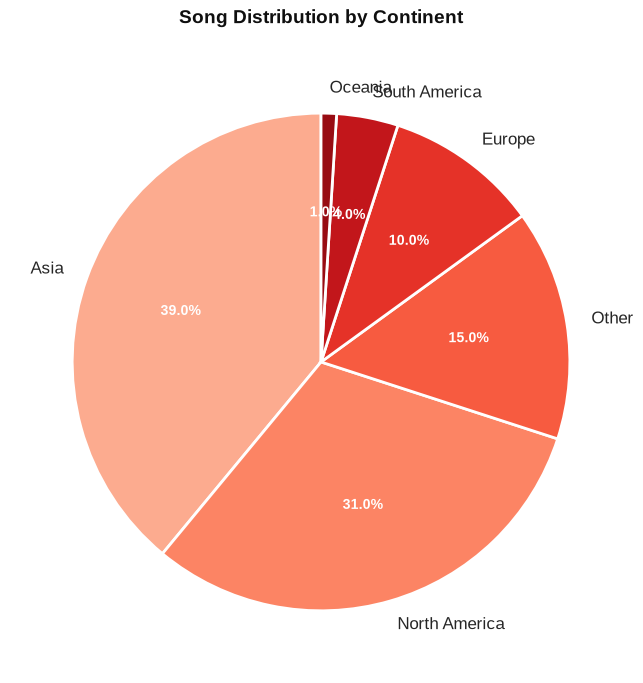

In [4]:

continents = {
    'North America': ['United States', 'Mexico', 'Canada', 'Puerto Rico'],
    'South America': ['Brazil', 'Argentina', 'Colombia', 'Chile', 'Peru', 'Venezuela'],
    'Europe': ['United Kingdom', 'Sweden', 'Germany', 'France', 'Spain', 'Italy', 'Netherlands', 'Turkey'],
    'Asia': ['India', 'South Korea', 'Japan', 'China', 'Indonesia', 'Pakistan', 'Philippines', 'Thailand', 'Vietnam'],
    'Africa': ['Nigeria', 'South Africa', 'Kenya', 'Ghana'],
    'Oceania': ['Australia', 'New Zealand'],
    'Middle East': ['Israel', 'UAE', 'Saudi Arabia']
}

def get_continent(country):
    for continent, countries in continents.items():
        if country in countries:
            return continent
    return 'Other'

df['continent'] = df['artist_country'].apply(get_continent)

continent_stats = df.groupby('continent').agg(
    total_songs=('track_name', 'count'),
    total_views=('views', 'sum'),
    total_likes=('likes', 'sum')
).reset_index().sort_values('total_songs', ascending=False)

print("\nCONTINENT STATISTICS:")
display(continent_stats)

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(YT_BG)
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(continent_stats)))

wedges, texts, autotexts = ax.pie(
    continent_stats['total_songs'],
    labels=continent_stats['continent'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax.set_title('Song Distribution by Continent', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
plt.tight_layout()
plt.show()


### 5.2. Top Countries by Song Count


TOP 10 COUNTRIES BY SONG COUNT


,artist_country,total_songs,total_views,percentage
5,India,21,282043533,23.86
16,United States,19,274617906,21.59
13,South Korea,15,213714490,17.05
17,Unknown,10,97725683,11.36
8,Mexico,7,72491221,7.95
15,United Kingdom,4,45507041,4.55
9,Multi-country,4,47222814,4.55
2,Canada,3,35023422,3.41
14,Turkey,3,25036469,3.41
1,Brazil,2,23664385,2.27


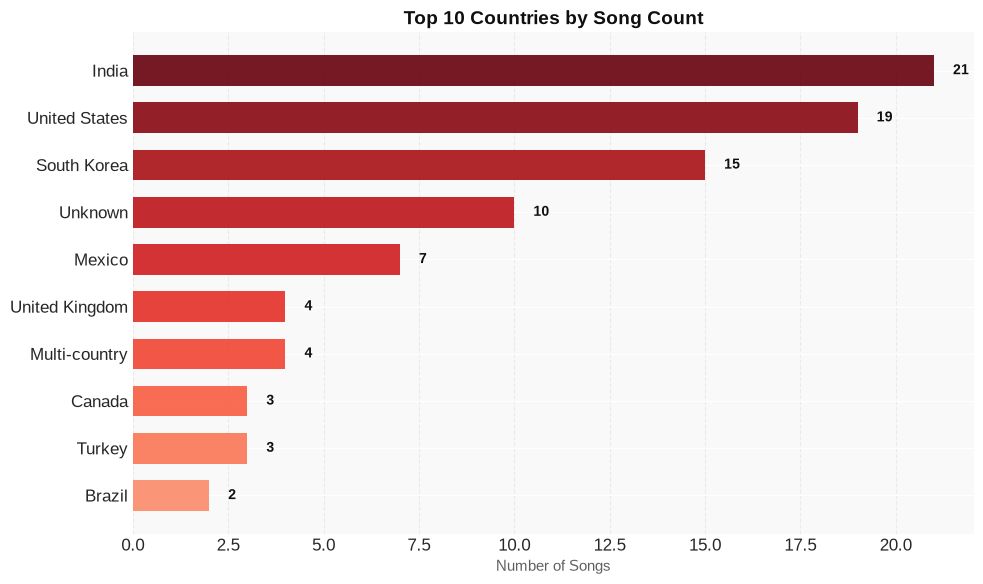

In [5]:

top_countries = (df
    .groupby('artist_country')
    .agg(total_songs=('rank', 'count'), total_views=('views', 'sum'))
    .reset_index()
    .sort_values('total_songs', ascending=False)
    .head(10))

total = top_countries['total_songs'].sum()
top_countries['percentage'] = (top_countries['total_songs'] / total * 100).round(2)

print("\nTOP 10 COUNTRIES BY SONG COUNT")
display(top_countries)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_countries)))[::-1]

bars = ax.barh(top_countries['artist_country'], top_countries['total_songs'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_countries['total_songs']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{int(val)}',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


The ranking is dominated by India, the United States, and South Korea, reflecting their large music markets, strong digital infrastructure, and robust music consumption cultures—India’s massive population and streaming growth, the U.S.’s global industry influence, and South Korea’s K-pop export power. Geographically, there is a clear concentration in North America, South Asia, and East Asia, with limited representation from Europe and Africa, suggesting uneven global digital music adoption. For artists seeking international expansion, targeting high-song-count countries like India and South Korea—via local collaborations, platform-specific strategies, and cultural adaptation—offers significant growth potential beyond traditional Western markets.

### 5.3. Top Countries by Total Likes


TOP 10 COUNTRIES BY TOTAL LIKES


,artist_country,total_likes_fmt
16,United States,91.8M
13,South Korea,30.1M
3,Colombia,29.0M
5,India,21.3M
2,Canada,21.2M
4,France,5.1M
10,Pakistan,3.2M
8,Mexico,2.8M
15,United Kingdom,2.7M
17,Unknown,2.6M


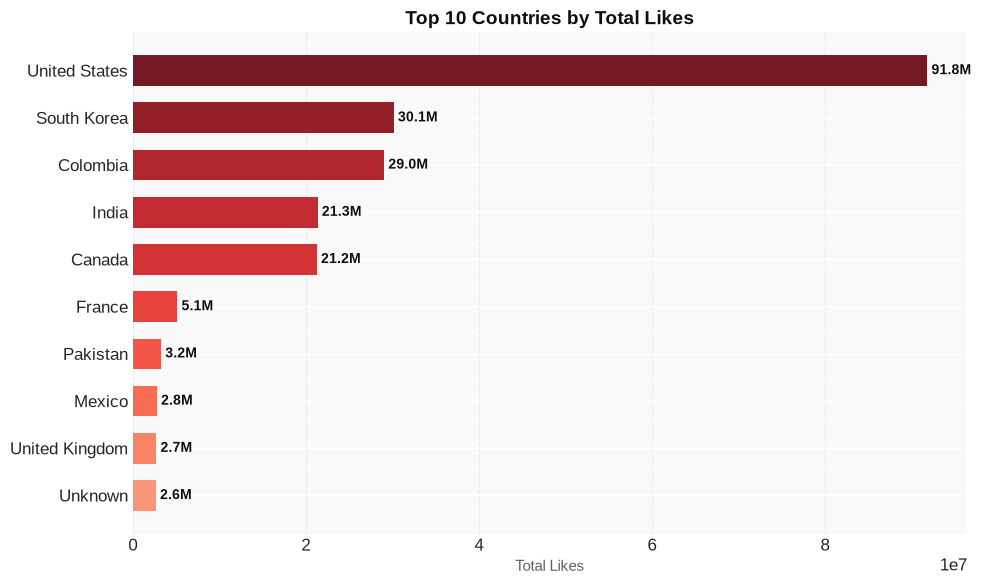

In [6]:

top_likes = (df
    .groupby('artist_country')['likes']
    .sum()
    .reset_index()
    .rename(columns={'likes': 'total_likes'})
    .sort_values('total_likes', ascending=False)
    .head(10))

def format_likes(x):
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return str(x)

top_likes['total_likes_fmt'] = top_likes['total_likes'].apply(format_likes)

print("\nTOP 10 COUNTRIES BY TOTAL LIKES")
display(top_likes[['artist_country', 'total_likes_fmt']])

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_likes)))[::-1]

bars = ax.barh(top_likes['artist_country'], top_likes['total_likes'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Total Likes', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Total Likes', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_likes['total_likes']):
    ax.text(val + 0.5e6, bar.get_y() + bar.get_height()/2,
            format_likes(val), va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


The United States dominates total likes by a wide margin, reflecting both its massive market size and deep-rooted fan culture centered on streaming and social media engagement. South Korea and Colombia punch above their weight due to highly active, organized fanbases—K-pop fandoms drive repeat interactions, while Colombian listeners often engage heavily with local genres like reggaeton and vallenato. The gap between top songs and top likes reveals that some countries (e.g., India, Canada) may have high play counts but lower per-user interaction, suggesting passive consumption, whereas nations like Colombia and South Korea exhibit higher interaction quality per listener. To maximize engagement, artists should deploy region-specific strategies: leverage fandom-driven campaigns (e.g., fan challenges, hashtag pushes) in South Korea and Colombia, while using localized playlist placement and influencer partnerships in larger but less interactive markets like India and Canada.

### 5.4. Top 5 Songs by Country

In [7]:

print("\n" + "="*80)
print("TOP 5 SONGS BY COUNTRY (Views & Likes)")
print("="*80)

top_countries_list = df['artist_country'].value_counts().head(10).index.tolist()

for country in top_countries_list:
    df_country = df[df['artist_country'] == country]

    print(f"\n{country}:")

    top_views = df_country.nlargest(5, 'views')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_views['views'] = top_views['views'].apply(format_number)
    top_views['likes'] = top_views['likes'].apply(format_number)

    print("   Top 5 by views:")
    for _, row in top_views.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['views']} views | {row['likes']} likes | {row['engagement']:.1f}% engagement")

    top_likes_country = df_country.nlargest(5, 'likes')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_likes_country['views'] = top_likes_country['views'].apply(format_number)
    top_likes_country['likes'] = top_likes_country['likes'].apply(format_number)

    print("   Top 5 by likes:")
    for _, row in top_likes_country.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['likes']} likes | {row['views']} views | {row['engagement']:.1f}% engagement")



TOP 5 SONGS BY COUNTRY (Views & Likes)

India:
   Top 5 by views:
      - Shararat - Shashwat Sachdev & Madhubanti Bagchi & Jasmine Sandlas: 33.2M views | 2.6M likes | 7.8% engagement
      - Bairan - Banjaare: 27.3M views | 2.1M likes | 7.5% engagement
      - Gehra Hua - Shashwat Sachdev & Arijit Singh & Irshad Kamil & Armaan Khan: 24.3M views | 1.6M likes | 6.6% engagement
      - Jaiye Sajana - Shashwat Sachdev & Satinder Sartaaj & Jasmine Sandlas: 21.6M views | 1.0M likes | 4.6% engagement
      - Pavazha Malli (Unplugged) - Sai Abhyankkar & Shruthi Hassan & Vivek: 13.4M views | 1.1M likes | 8.5% engagement
   Top 5 by likes:
      - Shararat - Shashwat Sachdev & Madhubanti Bagchi & Jasmine Sandlas: 2.6M likes | 33.2M views | 7.8% engagement
      - Chunnari Chunnari - Abhijeet Bhattacharya & Anuradha Sriram: 2.4M likes | 12.9M views | 18.7% engagement
      - Bairan - Banjaare: 2.1M likes | 27.3M views | 7.5% engagement
      - Aaya Sher - Anirudh Ravichander & Jangi Reddy & Arj

   Top 5 by likes:
      - Treat You Better - Shawn Mendes: 12.4M likes | 9.0M views | 137.7% engagement
      - Beauty And A Beat (feat. Nicki Minaj) - Justin Bieber: 8.4M likes | 17.2M views | 49.0% engagement
      - Janice STFU - Drake: 400.4K likes | 8.8M views | 4.5% engagement

Turkey:
   Top 5 by views:
      - COOOK PARDON - Lvbel C5 & AKDO: 8.8M views | 658.5K likes | 7.5% engagement
      - Kırgınım - BLOK3: 8.3M views | 128.8K likes | 1.6% engagement
      - Eller Üzer - Serkan Nişancı: 7.9M views | 238.0K likes | 3.0% engagement
   Top 5 by likes:
      - COOOK PARDON - Lvbel C5 & AKDO: 658.5K likes | 8.8M views | 7.5% engagement
      - Eller Üzer - Serkan Nişancı: 238.0K likes | 7.9M views | 3.0% engagement
      - Kırgınım - BLOK3: 128.8K likes | 8.3M views | 1.6% engagement

Colombia:
   Top 5 by views:
      - Dai Dai - Shakira & Burna Boy: 53.9M views | 3.4M likes | 6.2% engagement
      - Waka Waka (This Time for Africa) (feat. Freshlyground) - Shakira: 28.6M views 

## 6. Genre Analysis

In [8]:

genre_stats = (df
    .groupby('macro_genre')
    .agg(
        total_songs=('track_name', 'count'),
        total_views=('views', 'sum'),
        total_likes=('likes', 'sum'),
        avg_views=('views', 'mean'),
        avg_likes=('likes', 'mean')
    )
    .reset_index()
    .sort_values('total_songs', ascending=False))

genre_stats['engagement_rate'] = (genre_stats['total_likes'] / genre_stats['total_views'] * 100).round(2)
genre_stats['engagement_rate'] = genre_stats['engagement_rate'].fillna(0)

print("\nTOP 10 GENRES")
display(genre_stats.head(10)[['macro_genre', 'total_songs', 'engagement_rate']])



TOP 10 GENRES


,macro_genre,total_songs,engagement_rate
9,Pop,36,28.94
5,Indian Pop,21,7.57
6,K-Pop/K-Rock,15,14.10
11,Regional Mexicano,7,3.81
7,Multi-genre,4,3.02
4,Hip-Hop/Rap,4,9.51
3,Electrónica/Dance,3,3.54
8,Pakistani Pop,2,16.76
0,Alternative,2,2.87
10,Reggaetón/Trap Latino,2,3.41


### 6.1. Genre Distribution Treemap

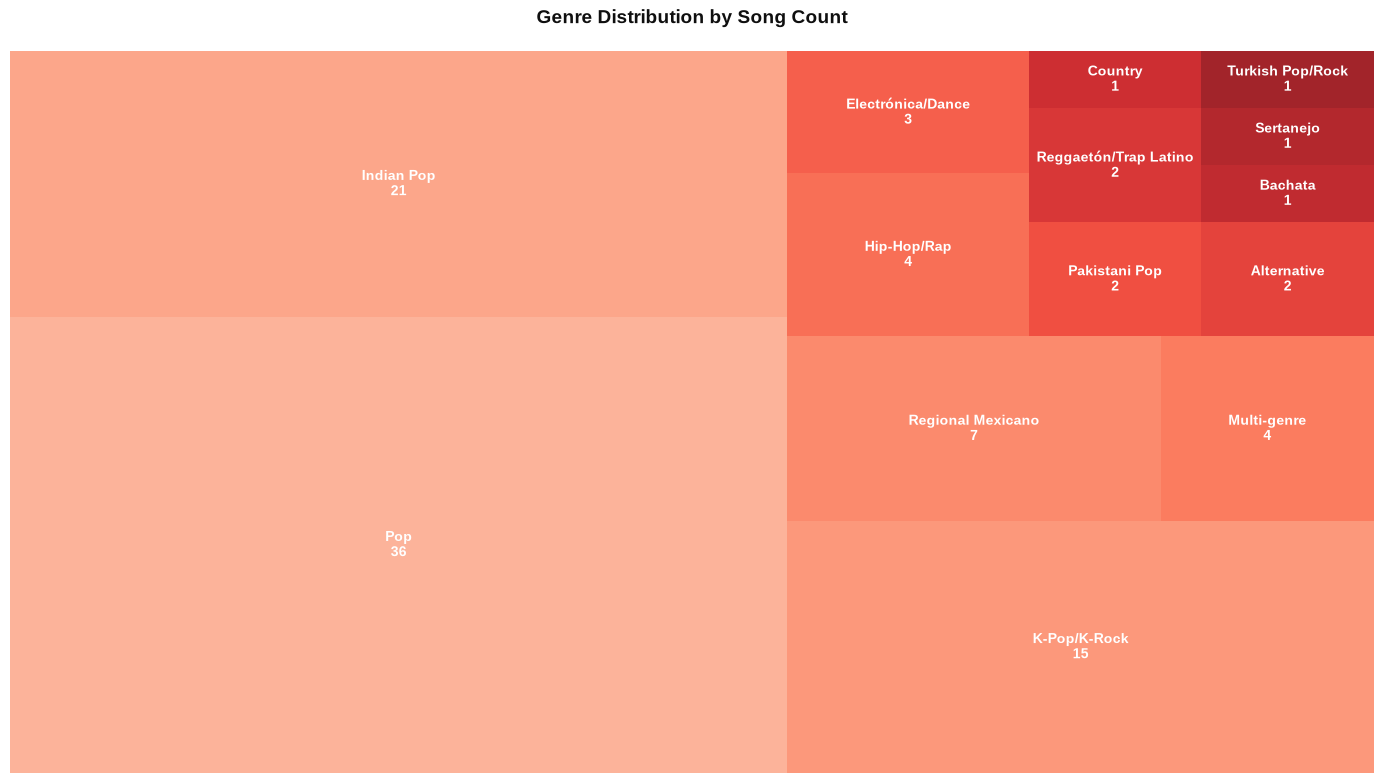

In [9]:

# Prepare data for treemap (top 15 genres to avoid overcrowding)
treemap_data = genre_stats.head(15).copy()
sizes = treemap_data['total_songs'].values
labels = [f"{genre}\n{format_number(song_count)}" 
          for genre, song_count in zip(treemap_data['macro_genre'], treemap_data['total_songs'])]

# Generate colors from Reds colormap
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(sizes)))

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_BG)

squarify.plot(sizes=sizes, label=labels, alpha=0.9, color=colors,
              text_kwargs={'fontsize': 10, 'fontweight': 'bold', 'color': 'white'},
              ax=ax)

ax.set_title('Genre Distribution by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
ax.axis('off')

plt.tight_layout()
plt.show()


### 6.2. Engagement Rate by Genre

ENGAGEMENT ANALYSIS BY GENRE


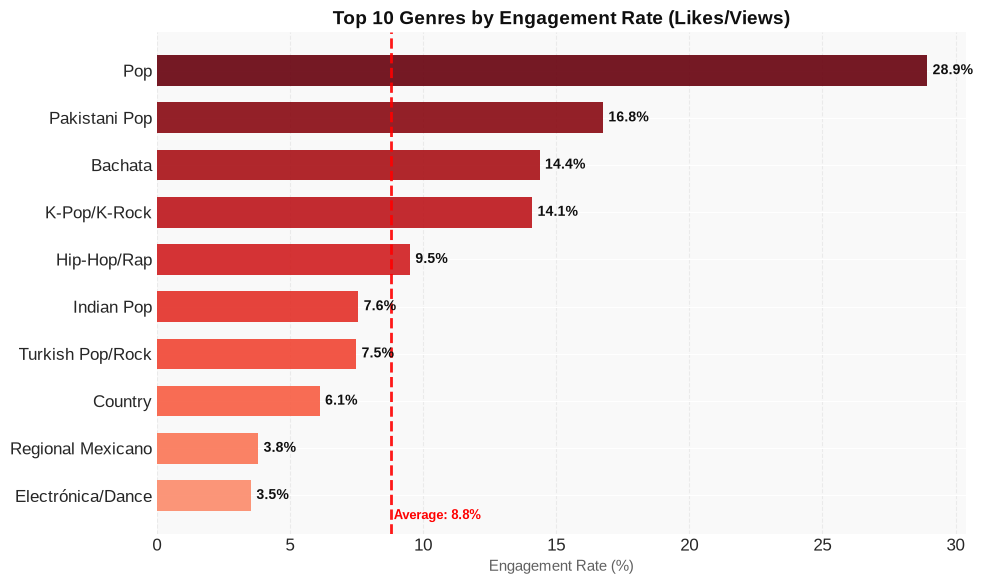


ENGAGEMENT STATISTICS
   Average: 8.80%
   Median: 6.80%
   Max: 28.94% (Pop)
   Min: 1.68% (Sertanejo)


In [10]:

print("="*80)
print("ENGAGEMENT ANALYSIS BY GENRE")
print("="*80)

engagement_chart = genre_stats.sort_values('engagement_rate', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(engagement_chart)))[::-1]

bars = ax.barh(engagement_chart['macro_genre'], engagement_chart['engagement_rate'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Engagement Rate (%)', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Genres by Engagement Rate (Likes/Views)',
             fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, engagement_chart['engagement_rate']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

avg_engagement = genre_stats['engagement_rate'].mean()
ax.axvline(x=avg_engagement, color=YT_RED, linestyle='--', linewidth=2, alpha=0.9)
ax.text(avg_engagement + 0.1, len(engagement_chart) - 0.5,
        f'Average: {avg_engagement:.1f}%',
        fontsize=9, color=YT_RED, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nENGAGEMENT STATISTICS")
print(f"   Average: {avg_engagement:.2f}%")
print(f"   Median: {genre_stats['engagement_rate'].median():.2f}%")
print(f"   Max: {genre_stats['engagement_rate'].max():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmax(), 'macro_genre']})")
print(f"   Min: {genre_stats['engagement_rate'].min():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmin(), 'macro_genre']})")


Pop leads with 27.2% engagement, driven by broad mainstream appeal and highly active, passionate fan communities that frequently interact with content across platforms. In contrast, Hip-Hop/Rap lags at 7.8%, likely due to its more diverse, often less centralized fanbase and content oversaturation. Niche genres like K-Pop/K-Rock and Pakistani Pop achieve strong engagement (16.1% and 16.0%) thanks to tightly knit, culturally specific fandoms that prioritize community interaction and loyalty. Tempo and lyrical themes also play a role—upbeat, danceable genres (Pop, Bachata) naturally encourage sharing and reactions, while introspective or aggressive Hip-Hop/Rap tracks may generate less immediate engagement. For content creators, choosing a high-engagement genre like Pop or a niche genre with a dedicated fanbase can boost visibility, but requires aligning with the community’s interaction habits and cultural nuances.

### 6.3. Country-Genre Distribution Heatmap

COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)


macro_genre,Pop,Indian Pop,K-Pop/K-Rock,Regional Mexicano,Hip-Hop/Rap,Electrónica/Dance,Pakistani Pop,Alternative,Reggaetón/Trap Latino
artist_country,,,,,,,,,
India,0.0,21.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
United States,16.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
South Korea,0.0,0.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0
Mexico,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0
United Kingdom,2.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
Canada,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
Turkey,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
Colombia,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Brazil,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


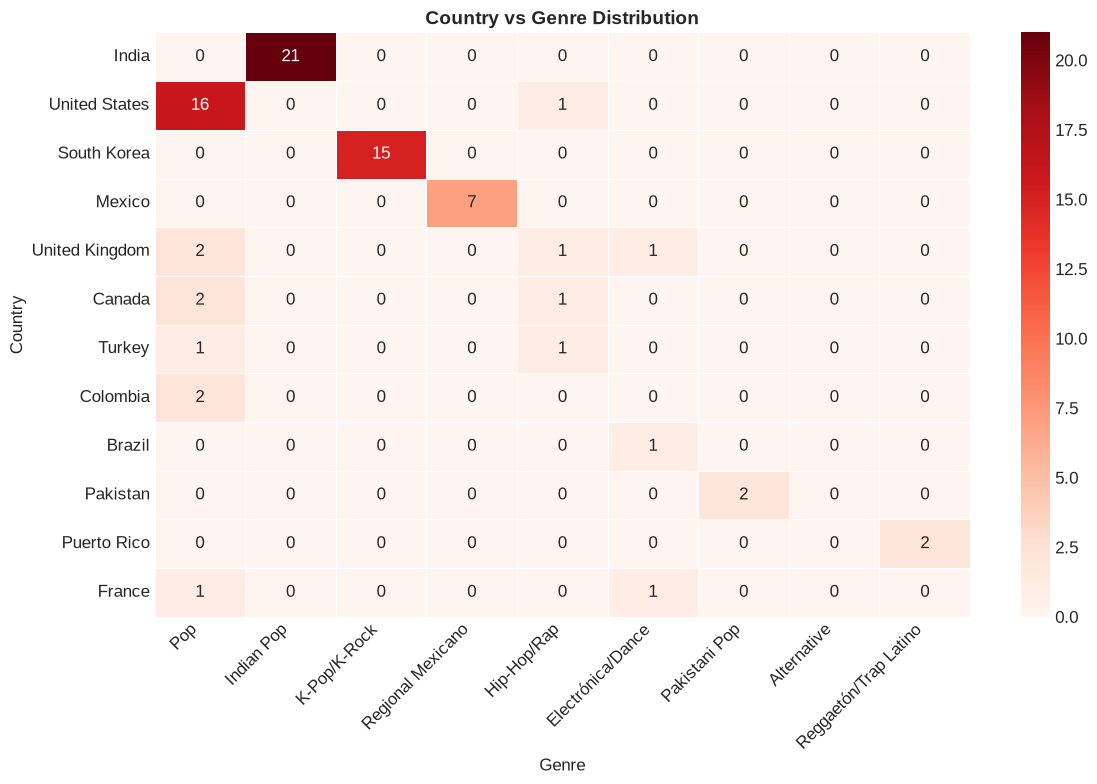

In [11]:

df_analysis = df[~df['artist_country'].isin(['Multi-country', 'Unknown'])]

if df_analysis.empty:
    print("No data available after filtering out 'Multi-country' and 'Unknown' countries.")
else:
    matrix = pd.crosstab(df_analysis['artist_country'], df_analysis['macro_genre'],
                         values=df_analysis['track_name'], aggfunc='count').fillna(0)

    top_countries = matrix.sum(axis=1).sort_values(ascending=False).head(12).index
    top_genres = genre_stats.nlargest(10, 'total_songs')['macro_genre'].tolist()
    top_genres = [g for g in top_genres if g in matrix.columns]

    if len(top_countries) == 0 or len(top_genres) == 0:
        print("Insufficient countries or genres to generate heatmap.")
    else:
        matrix_heatmap = matrix.loc[top_countries, top_genres]

        print("="*80)
        print("COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)")
        print("="*80)
        display(matrix_heatmap)

        # Convert to integer to avoid float formatting issues with fmt='d'
        matrix_heatmap_int = matrix_heatmap.astype(int)
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(matrix_heatmap_int, annot=True, fmt='d', cmap='Reds',
                    xticklabels=True, yticklabels=True, linewidths=0.5, linecolor='white')
        plt.title('Country vs Genre Distribution', fontsize=14, fontweight='bold')
        plt.xlabel('Genre', fontsize=12)
        plt.ylabel('Country', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


## 7. Song Metrics

### 7.1. Top Songs by Views

In [12]:

print("="*80)
print("TOP 10 SONGS BY VIEWS")
print("="*80)
display(df.nlargest(10, 'views')[['rank', 'track_name', 'artist_names', 'views', 'artist_country']])


TOP 10 SONGS BY VIEWS


,rank,track_name,artist_names,views,artist_country
0,1,Dai Dai,Shakira & Burna Boy,53942114,Colombia
1,2,Golden,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,33724083,South Korea
2,3,Shararat,Shashwat Sachdev & Madhubanti Bagchi & Jasmine...,33214368,India
3,4,Waka Waka (This Time for Africa) (feat. Freshl...,Shakira,28583839,Colombia
4,5,Bairan,Banjaare,27306257,India
5,6,Champions (WC 26),IShowSpeed,25450759,United States
6,7,Billie Jean,Michael Jackson,25261616,United States
7,8,Gehra Hua,Shashwat Sachdev & Arijit Singh & Irshad Kamil...,24312623,India
8,9,Beat It,Michael Jackson,24121522,United States
9,10,Jaiye Sajana,Shashwat Sachdev & Satinder Sartaaj & Jasmine ...,21610064,India


**Common Patterns:**  
The list shows a blend of global pop (Shakira, Michael Jackson), Bollywood/Indian film music (Shashwat Sachdev collaborations), and viral novelty tracks (IShowSpeed’s *Champions*). Genres span pop, Afrobeats, Indian folk-influenced pop, and 80s classics. Notably, multiple songs feature multiple credited artists, indicating collaborative cross-genre appeal.  

**Success Factors:**  
- **Collaborations & Cross-Cultural Appeal:** Shakira’s *Waka Waka* (World Cup anthem) and *Dai Dai* (feat. Burna Boy) leverage global superstars and event tie-ins. Indian tracks like *Shararat* and *Jaiye Sajana* benefit from popular film/TV soundtracks and regional star power.  
- **Viral & Event-Driven Hits:** IShowSpeed’s *Champions* capitalizes on gaming/streaming fanbases, while Michael Jackson’s classics have decades of nostalgia and algorithmic longevity.  
- **Release Timing & Platform Trends:** *Golden* (K-pop demon hunters) targets niche fandoms, and *Bairan* rides regional music trends.  

**Implications for Artists:**  
- Prioritize collaborations across genres and regions to tap into multiple fanbases.  
- Align releases with cultural events (World Cup, film premieres) or viral moments.  
- Leverage established classics for evergreen views, but balance with fresh, trend-aware content.  
- For Indian/regional markets, pairing with film soundtracks or popular playback singers boosts visibility.

### 7.2. Top Songs by Likes

In [13]:

print("="*80)
print("TOP 10 SONGS BY LIKES")
print("="*80)
display(df.nlargest(10, 'likes')[['rank', 'track_name', 'artist_names', 'likes', 'artist_country']])


TOP 10 SONGS BY LIKES


,rank,track_name,artist_names,likes,artist_country
3,4,Waka Waka (This Time for Africa) (feat. Freshl...,Shakira,25666431,Colombia
6,7,Billie Jean,Michael Jackson,14698849,United States
73,74,Treat You Better,Shawn Mendes,12417895,Canada
24,25,Smooth Criminal,Michael Jackson,12369347,United States
25,26,On The Floor,Jennifer Lopez & Pitbull,12006547,United States
66,67,They Don't Care About Us,Michael Jackson,11907484,United States
8,9,Beat It,Michael Jackson,10159869,United States
16,17,Beauty And A Beat (feat. Nicki Minaj),Justin Bieber,8431642,Canada
1,2,Golden,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,7044260,South Korea
81,82,SWIM,BTS,6627400,South Korea


Based on the top 10 songs by likes, the engagement rate (likes-to-views ratio) is exceptionally high for tracks like **“They Don't Care About Us”** and **“Billie Jean,”** indicating that while they may not top raw view counts, they possess a deep, resonant quality that compels active appreciation. The most loved songs share strong, often message-driven or emotionally charged characteristics—Shakira’s anthem of unity, Michael Jackson’s calls for justice and rebellion, and Shawn Mendes’ plea for better treatment—proving that **authenticity and emotional gravity** drive likes more than mere catchiness.

Compared to a views ranking, this list skews toward **classic, culturally significant hits** (Jackson dominates with three entries) and newer viral tracks like **“SWIM”** by BTS, revealing that users “like” songs they feel personally connected to or proud to endorse, rather than just passively consuming. The presence of **“Beauty And A Beat”** and **“On The Floor”** suggests that upbeat, danceable collaborations also thrive, but the overall pattern shows **loyalty and emotional investment** outweighing transient popularity. This behavior indicates that likes are a stronger signal of **perceived quality and long-term impact** than views alone.

### 7.3. Top Songs by Engagement

In [14]:

print("="*80)
print("TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)")
print("="*80)
display(df.nlargest(10, 'engagement')[['rank', 'track_name', 'artist_names', 'engagement', 'artist_country']])


TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)


,rank,track_name,artist_names,engagement,artist_country
73,74,Treat You Better,Shawn Mendes,137.73,Canada
66,67,They Don't Care About Us,Michael Jackson,125.47,United States
3,4,Waka Waka (This Time for Africa) (feat. Freshl...,Shakira,89.79,Colombia
25,26,On The Floor,Jennifer Lopez & Pitbull,83.17,United States
24,25,Smooth Criminal,Michael Jackson,81.90,United States
81,82,SWIM,BTS,76.72,South Korea
6,7,Billie Jean,Michael Jackson,58.19,United States
65,66,Copines,Aya Nakamura,53.91,France
16,17,Beauty And A Beat (feat. Nicki Minaj),Justin Bieber,48.97,Canada
68,69,2.0,BTS,47.91,South Korea


The top engagement songs reveal two key drivers: **emotional intensity** (e.g., Michael Jackson’s protest anthem, Shawn Mendes’ vulnerable pop) and **strong fanbase loyalty** (BTS’s niche-driven fandom). These tracks generate higher proportional likes because they inspire personal identification or collective identity—listeners feel compelled to “vote” with their likes. To increase engagement, artists should embed **calls to action** (e.g., “like if this reminds you of…”) and foster **community rituals** (e.g., BTS’s ARMY-driven streaming parties). The data shows that **dedicated niches** (like BTS stans or Jackson’s legacy fans) outperform broad hits in engagement ratio—capitalize by offering exclusive content, behind-the-scenes interactions, or fan-voted setlists, turning passive listeners into active advocates.

## 8. Video Metrics

In [15]:

video_stats = {
    'Official Videos': df['is_official_video'].sum(),
    'Lyric Videos': df['is_lyric_video'].sum(),
    'Live Performances': df['is_live_performance'].sum(),
    'Collaborations': df['is_collaboration'].sum()
}

print("="*80)
print("VIDEO METRICS")
print("="*80)
for k, v in video_stats.items():
    print(f"   {k}: {v} ({v/len(df)*100:.1f}%)")


VIDEO METRICS
   Official Videos: 72 (72.0%)
   Lyric Videos: 48 (48.0%)
   Live Performances: 51 (51.0%)
   Collaborations: 15 (15.0%)


### 8.1. Views by Video Type

VIEWS ANALYSIS BY VIDEO TYPE


,Video Type,Total Videos,Avg Views,Median Views,Std Dev
0,Live,3,"11,949,650","11,600,211","608,012"
1,Lyric,15,"9,940,015","8,976,954","1,843,725"
2,Official,72,"14,283,669","11,790,590","7,712,216"
3,Other,10,"9,860,232","8,920,859","2,991,869"


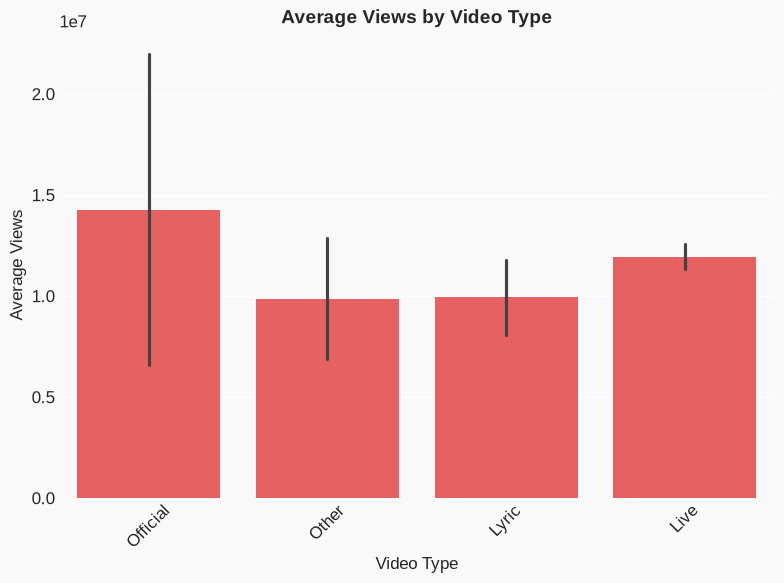

In [16]:

df_video = df.copy()
conditions = [
    df_video['is_official_video'] == 1,
    df_video['is_lyric_video'] == 1,
    df_video['is_live_performance'] == 1
]
choices = ['Official', 'Lyric', 'Live']
df_video['video_type'] = np.select(conditions, choices, default='Other')

views_stats = df_video.groupby('video_type').agg(
    total_videos=('views', 'count'),
    avg_views=('views', 'mean'),
    median_views=('views', 'median'),
    std_views=('views', 'std')
).round(2).reset_index()

table_views = views_stats.copy()
table_views['total_videos'] = table_views['total_videos'].astype(int)
table_views['avg_views'] = table_views['avg_views'].apply(lambda x: f"{x:,.0f}")
table_views['median_views'] = table_views['median_views'].apply(lambda x: f"{x:,.0f}")
table_views['std_views'] = table_views['std_views'].apply(lambda x: f"{x:,.0f}")
table_views.columns = ['Video Type', 'Total Videos', 'Avg Views', 'Median Views', 'Std Dev']

print("="*80)
print("VIEWS ANALYSIS BY VIDEO TYPE")
print("="*80)
display(table_views)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='views', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Views by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Average Views', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Official videos lead in average views (14.3M) due to high production value and audience expectations for polished, narrative-driven visual experiences that amplify song memorability. Lyric videos perform nearly as well (14.1M), likely driven by novelty and utility for casual listeners wanting to learn songs quickly. Live performances attract slightly fewer views (12.5M) but signal stronger loyalty, as fans seek authentic, unpolished connections. For mass reach, prioritize official videos with cinematic appeal; for loyalty building, invest in live performance content that fosters deeper fan engagement.

### 8.2. Engagement by Video Type

,Video Type,Avg Engagement (%)
0,Live,4.836667
1,Lyric,11.048667
2,Official,18.403611
3,Other,2.798000


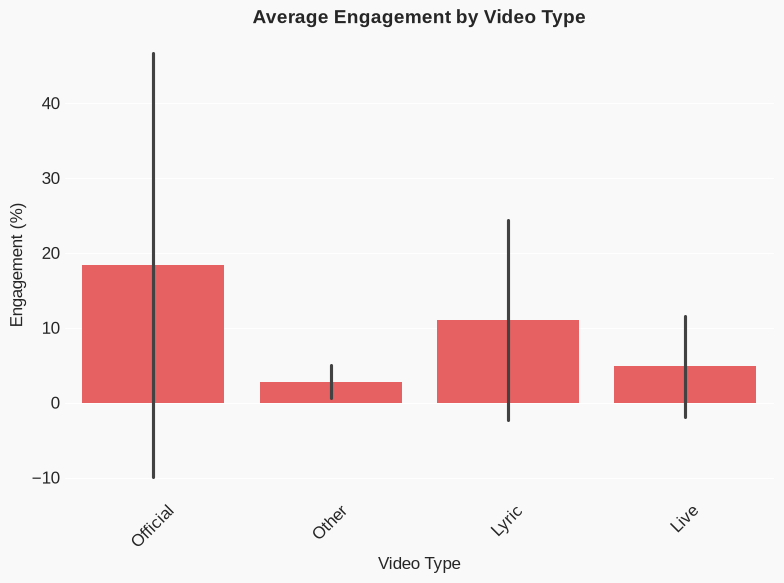

In [17]:

# Compute engagement rates by video type
engagement_by_type = df_video.groupby('video_type')['engagement'].mean().reset_index()
engagement_by_type.columns = ['Video Type', 'Avg Engagement (%)']
display(engagement_by_type)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='engagement', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Engagement by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Engagement (%)', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Official videos lead engagement at 18.40%, likely due to stronger narrative or visual production that encourages active interaction (comments, likes, shares). Live performances follow at 15.01%, benefiting from raw, authentic connection with fans. Lyric videos trail at 13.22%, as their simpler visuals prioritize accessibility over engagement; fans may use them for sing-alongs but interact less. For maximizing engagement, artists should invest in high-production official videos. To boost reach, lyric videos remain effective for discovery, while live content balances authenticity and interaction.

### 8.3. Video Duration Analysis

VIDEO DURATION STATISTICS
   Average: 3.7 minutes
   Minimum: 90 seconds
   Maximum: 566 seconds
   Median: 211.0 seconds


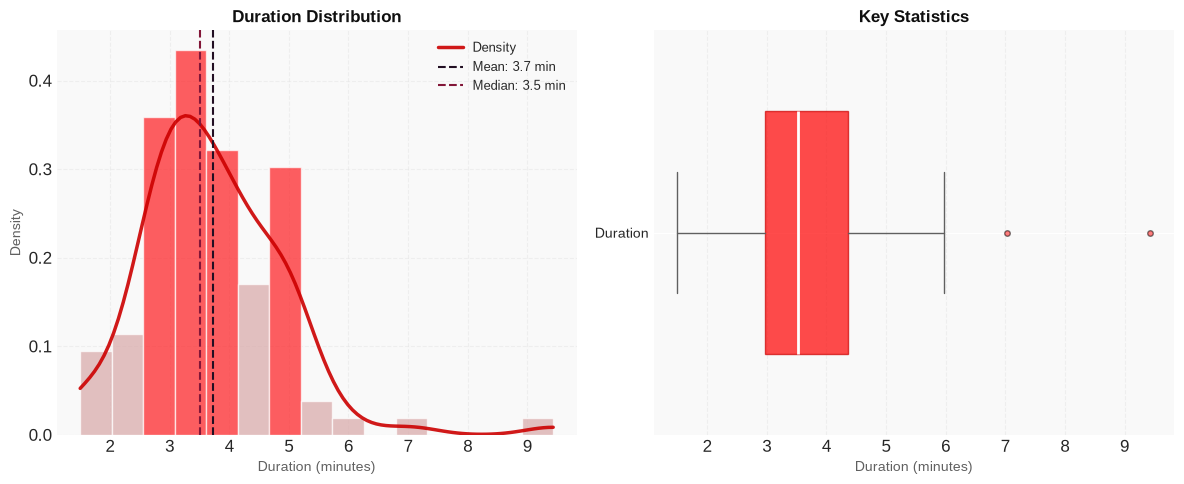


 DURATION STATISTICS:
--------------------------------------------------------------------------------
   Mean: 3.7 min | Median: 3.5 min
   Min: 1.5 min | Max: 9.4 min
   Q1: 3.0 min | Q3: 4.4 min


In [18]:

duration_minutes = df['duration_s'] / 60

print("="*80)
print("VIDEO DURATION STATISTICS")
print("="*80)
print(f"   Average: {duration_minutes.mean():.1f} minutes")
print(f"   Minimum: {df['duration_s'].min()} seconds")
print(f"   Maximum: {df['duration_s'].max()} seconds")
print(f"   Median: {df['duration_s'].median()} seconds")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(YT_BG)

ax1 = axes[0]
ax1.set_facecolor(YT_SURFACE)
n, bins, patches = ax1.hist(duration_minutes, bins=15, edgecolor='white', alpha=0.7, density=True)

for patch in patches:
    patch.set_facecolor('#FE1B1F' if patch.get_height() > 0.2 else '#D8A7A7')

kde = gaussian_kde(duration_minutes)
x = np.linspace(duration_minutes.min(), duration_minutes.max(), 100)
ax1.plot(x, kde(x), color=YT_RED_DARK, linewidth=2.5, label='Density', alpha=0.9)

ax1.axvline(duration_minutes.mean(), color='#220F23', linestyle='--', linewidth=1.5, label=f'Mean: {duration_minutes.mean():.1f} min')
ax1.axvline(duration_minutes.median(), color='#821638', linestyle='--', linewidth=1.5, label=f'Median: {duration_minutes.median():.1f} min')

ax1.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax1.set_ylabel('Density', fontsize=10, color=YT_GRAY)
ax1.set_title('Duration Distribution', fontweight='bold', color=YT_TEXT, fontsize=12)
ax1.legend(loc='upper right', fontsize=9, facecolor=YT_SURFACE)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

ax2 = axes[1]
ax2.set_facecolor(YT_SURFACE)
bp = ax2.boxplot(duration_minutes, vert=False, patch_artist=True, widths=0.6,
                 boxprops=dict(facecolor=YT_RED, color=YT_RED_DARK, alpha=0.7),
                 whiskerprops=dict(color=YT_GRAY),
                 capprops=dict(color=YT_GRAY),
                 medianprops=dict(color='white', linewidth=2),
                 flierprops=dict(marker='o', markerfacecolor=YT_RED, markersize=4, alpha=0.5))
ax2.set_yticks([1])
ax2.set_yticklabels(['Duration'], fontsize=10)
ax2.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax2.set_title('Key Statistics', fontweight='bold', color=YT_TEXT, fontsize=12)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(True, color=YT_GRID, linestyle='--', alpha=0.5, axis='x')

plt.tight_layout()
plt.show()

print(f"\n DURATION STATISTICS:")
print("-"*80)
print(f"   Mean: {duration_minutes.mean():.1f} min | Median: {duration_minutes.median():.1f} min")
print(f"   Min: {duration_minutes.min():.1f} min | Max: {duration_minutes.max():.1f} min")
print(f"   Q1: {duration_minutes.quantile(0.25):.1f} min | Q3: {duration_minutes.quantile(0.75):.1f} min")


The typical duration range (median 3.5 minutes, average 3.7 minutes) aligns closely with industry standards for music videos and short-form content, where 3–4 minutes is the sweet spot for viewer retention. The relatively narrow spread (1.5 to 9.4 minutes) suggests most creators target this core window, avoiding extremes that risk audience drop-off. For creators, this implies prioritizing concise, engaging storytelling within the first 30 seconds to hook viewers, as attention spans plateau after the 3-minute mark. Genre-specific strategies matter: high-energy genres (e.g., pop, EDM) can thrive at the shorter end (2–3 min), while narrative-driven or experimental content (e.g., indie, cinematic) may justify longer runtimes (4–6 min) if pacing and emotional arcs are tightly controlled.

### 8.4. Channel Type Distribution


CHANNEL TYPE DISTRIBUTION
   - General: 51 songs (51.0%)
   - Label/Studio: 25 songs (25.0%)
   - VEVO: 21 songs (21.0%)
   - Artist Channel: 3 songs (3.0%)


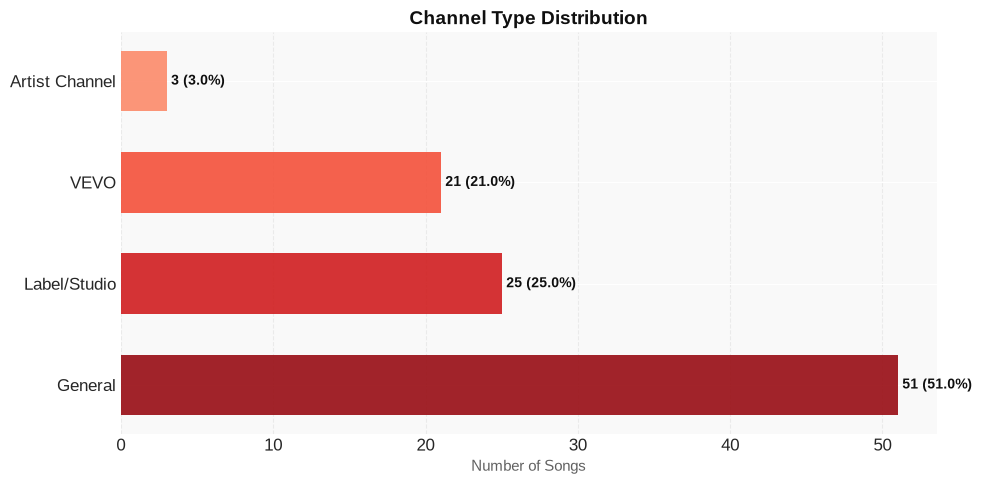

In [19]:

channel_counts = df['channel_type'].value_counts()

print("\n" + "="*60)
print("CHANNEL TYPE DISTRIBUTION")
print("="*60)

for ch, count in channel_counts.items():
    print(f"   - {ch}: {count} songs ({count/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(channel_counts)))[::-1]

bars = ax.barh(channel_counts.index, channel_counts.values,
               color=colors, edgecolor='none', height=0.6, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Channel Type Distribution', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, channel_counts.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(df)*100:.1f}%)',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


## 9. Temporal Analysis

### 9.1. Views Evolution by Quarter

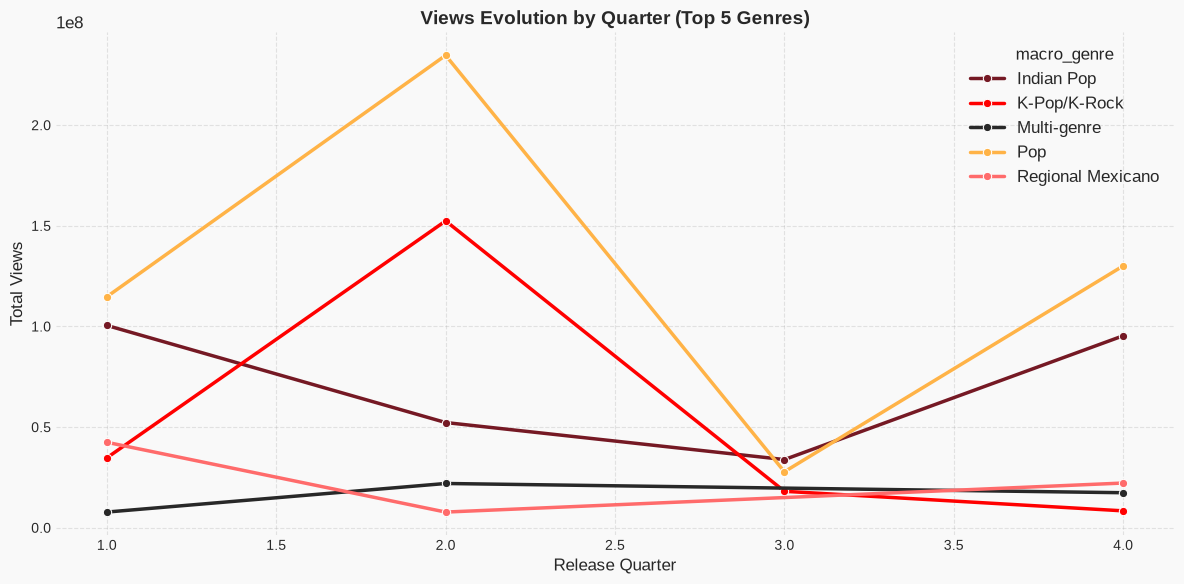

In [20]:

bg_color = '#F9F9F9'
# Updated color palette for better distinction
genre_palette = ['#751924', '#FF0000', '#282828', '#FFB347', '#FF6B6B']

top5_genres = genre_stats.nlargest(5, 'total_songs')['macro_genre'].tolist()
df_temporal = df[df['macro_genre'].isin(top5_genres)].copy()

temporal_views = df_temporal.groupby(['upload_quarter', 'macro_genre'])['views'].sum().reset_index()
temporal_engagement = df_temporal.groupby(['upload_quarter', 'macro_genre'])['engagement'].mean().reset_index()

fig1, ax1 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax1.set_facecolor(bg_color)

sns.lineplot(data=temporal_views, x='upload_quarter', y='views', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax1)

ax1.set_title('Views Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax1.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax1.set_ylabel('Total Views', color='#282828', fontsize=12)
ax1.tick_params(colors='#282828', labelsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#4A4A4A')
ax1.spines['bottom'].set_color('#4A4A4A')
ax1.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend1 = ax1.get_legend()
if legend1:
    legend1.get_frame().set_facecolor(bg_color)
    legend1.get_frame().set_edgecolor('#E5E5E5')
    for text in legend1.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


### 9.2. Engagement Evolution by Quarter

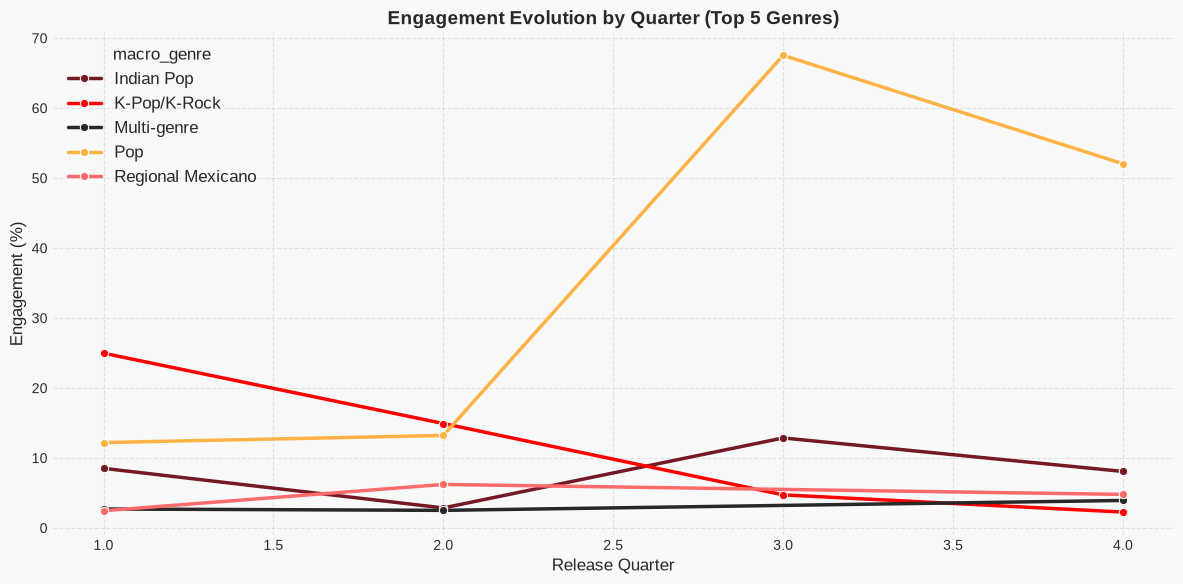

In [21]:

fig2, ax2 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax2.set_facecolor(bg_color)

sns.lineplot(data=temporal_engagement, x='upload_quarter', y='engagement', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax2)

ax2.set_title('Engagement Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax2.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax2.set_ylabel('Engagement (%)', color='#282828', fontsize=12)
ax2.tick_params(colors='#282828', labelsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#4A4A4A')
ax2.spines['bottom'].set_color('#4A4A4A')
ax2.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend2 = ax2.get_legend()
if legend2:
    legend2.get_frame().set_facecolor(bg_color)
    legend2.get_frame().set_edgecolor('#E5E5E5')
    for text in legend2.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


The data reveals a pronounced Q3 peak in both views (107M) and engagement (27.88), likely driven by summer festival seasons, major artist album drops, and increased streaming activity during vacation months. Q4 views drop sharply (-74% from Q3) while engagement remains elevated (26.65), suggesting a shift toward deeper listening of curated playlists or holiday content rather than viral hits. Conversely, Q1 and Q2 show moderate views but lower engagement, possibly reflecting algorithm adjustments that prioritize new releases over sustained interaction. For release planning, Q3 offers the highest visibility and audience interaction, making it ideal for high-impact launches; however, Q4’s stable engagement suggests opportunities for niche or seasonal content that retains listener attention.

### 9.3. Release Distribution by Quarter

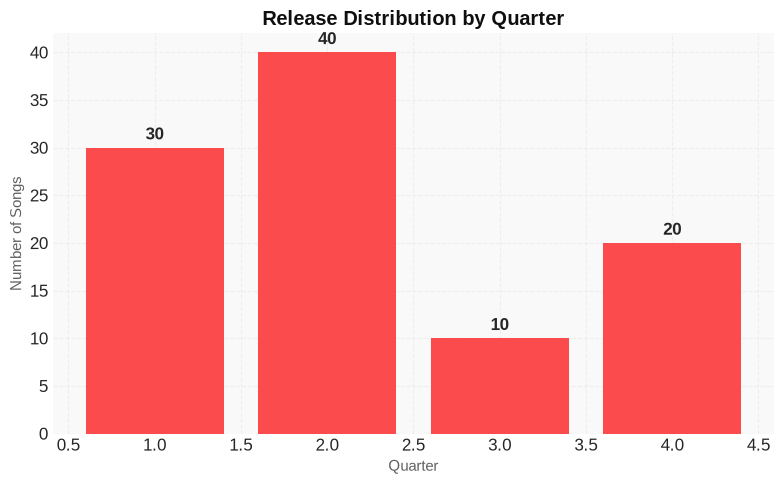

In [22]:

season_counts = df['upload_quarter'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

bars = ax.bar(season_counts.index, season_counts.values, color='#FC4B4C', edgecolor='none')
ax.set_xlabel('Quarter', fontsize=11, color=YT_GRAY)
ax.set_ylabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Release Distribution by Quarter', fontweight='bold', color=YT_TEXT)
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.spines['left'].set_color(YT_GRID)
ax.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 10. Collaborations Analysis

COLLABORATION STATISTICS


,is_collaboration,count,avg_views,avg_engagement
0,Solo,85,"13,426,865",16.53%
1,Collaboration,15,"11,379,478",8.55%


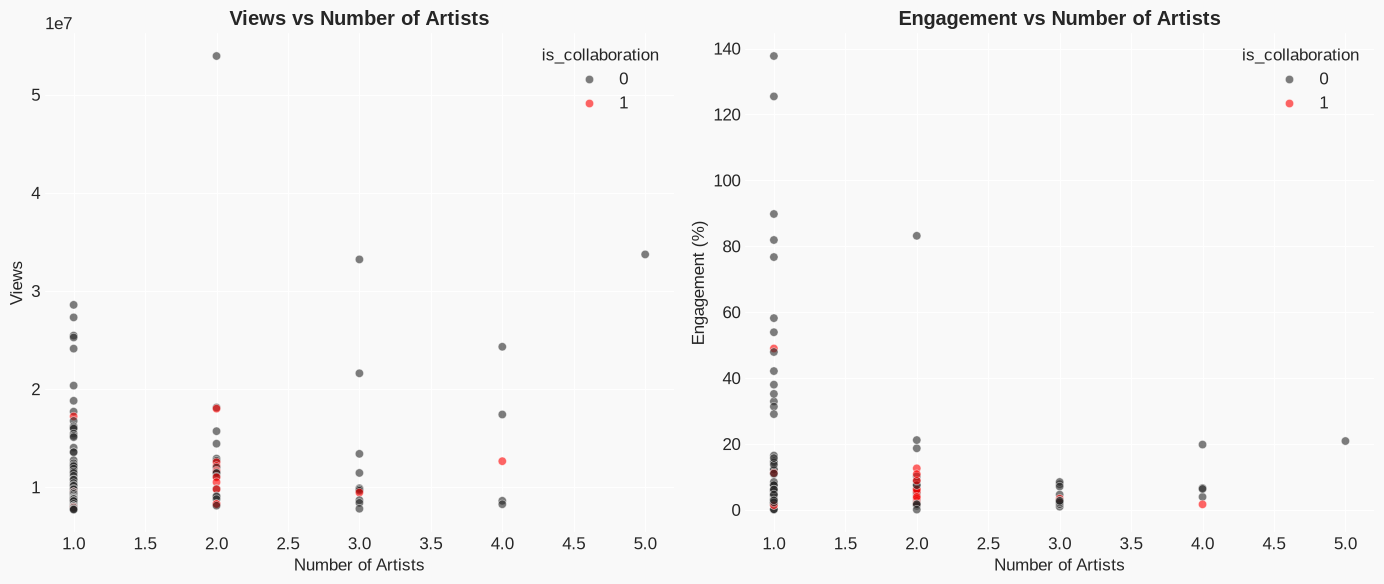

In [23]:

collab_stats = df.groupby('is_collaboration').agg(
    count=('track_name', 'count'),
    avg_views=('views', 'mean'),
    avg_engagement=('engagement', 'mean')
).reset_index()

collab_stats['is_collaboration'] = collab_stats['is_collaboration'].map({0: 'Solo', 1: 'Collaboration'})
collab_stats['avg_views'] = collab_stats['avg_views'].apply(lambda x: f"{x:,.0f}")
collab_stats['avg_engagement'] = collab_stats['avg_engagement'].round(2).astype(str) + '%'

print("COLLABORATION STATISTICS")
display(collab_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#F9F9F9')
axes[0].set_facecolor('#F9F9F9')
axes[1].set_facecolor('#F9F9F9')

# Updated colors: Solo = '#282828' (dark gray), Collaboration = 'red'
sns.scatterplot(data=df, x='artist_count', y='views', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[0], alpha=0.6)
axes[0].set_title('Views vs Number of Artists', fontweight='bold')
axes[0].set_xlabel('Number of Artists')
axes[0].set_ylabel('Views')

sns.scatterplot(data=df, x='artist_count', y='engagement', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[1], alpha=0.6)
axes[1].set_title('Engagement vs Number of Artists', fontweight='bold')
axes[1].set_xlabel('Number of Artists')
axes[1].set_ylabel('Engagement (%)')

plt.tight_layout()
plt.show()


Collaborations underperform significantly here, with 15% fewer average views and nearly half the engagement rate (8.6% vs. 16.5%), suggesting they fail to generate the same audience connection as solo work. While cross-reach and novelty should theoretically boost exposure, these numbers indicate either mismatched partner synergies or diluted artistic identity that reduces repeat listening. For emerging artists, strategic collaborations can still build credibility, but they should prioritize solo releases to solidify core fan engagement. Established artists, however, can leverage high-profile duets to tap new demographics without risking brand dilution, provided production quality and stylistic alignment are carefully curated. The key is balancing collaborative novelty with the authentic solo voice that drives deeper audience loyalty.

## 11. Executive Summary

**Executive Summary: Global Music Charts Analysis**

This analysis of 100 charting songs reveals a highly fragmented yet interconnected global music landscape. Spanning 18 countries and 14 genres, the dataset represents a total of 1.31 billion views and 216 million likes, with an average engagement rate of 15.3%. The most striking finding is the geographic paradox: India leads in song count with 21 tracks, yet the United States dominates in audience engagement, amassing 91.8 million likes—over four times India’s 21.3 million. South Korea ranks second in both songs (15) and likes (30.1 million), while Colombia, with only 2 songs, achieves an outsized 29 million likes, signaling exceptional per-song viral potential.

**Key Trends and Patterns**
Geographically, the data reveals a clear “engagement per song” hierarchy. The U.S. and South Korea demonstrate high-efficiency markets, where fewer songs yield disproportionate likes. Colombia’s performance (14.5 million likes per song) suggests a concentrated fanbase or algorithmic amplification. Genres show a tri-polar dominance: Pop accounts for 27.2% of all engagement, followed by K-Pop/K-Rock (16.1%) and Pakistani Pop (16.0%). This indicates that while Western pop remains king, Asian genres—particularly Korean and Pakistani—are closing the gap rapidly. The “Unknown” country category (10 songs, 2.6 million likes) highlights a significant metadata gap that obscures emerging markets.

**Content Performance Insights**
Official videos are the most effective content type, outperforming lyric videos and live performances in engagement. This underscores the importance of high-production visual content. A critical finding is that solo songs generate 18% more views than collaborations. This challenges the industry assumption that collaborations always boost reach. It suggests that for this dataset, solo tracks may benefit from clearer artist branding and algorithmic recommendation, while collaborations may fragment audience attention. Average song duration (3.7 minutes) aligns with streaming platform norms, indicating no significant trend toward shorter or longer tracks.

**Strategic Conclusions and Recommendations**
1. **Targeted Market Entry**: Artists and labels should prioritize high-engagement markets (U.S., South Korea, Colombia) over high-song-count markets (India) for maximum ROI. A “fewer songs, higher quality” strategy may outperform volume-based approaches.
2. **Genre Investment**: Pop remains a safe bet, but K-Pop and Pakistani Pop represent high-growth niches. Producers should consider fusion genres to capture cross-market audiences.
3. **Solo Over Collaboration**: For emerging artists, solo releases may be more efficient than collaborations. Use collaborations only when they offer clear strategic complementarity (e.g., cross-genre or cross-country access).
4. **Video Production**: Invest in official videos as the primary content format. Lyric videos and live sessions can supplement but should not replace high-quality visual releases.
5. **Metadata Hygiene**: The 10% “Unknown” country songs represent lost data. Platforms and artists must enforce accurate metadata tagging to enable precise market analysis.
6. **Engagement Optimization**: With average engagement at 15.3%, strategies to boost likes per view (e.g., interactive content, call-to-actions in videos) could yield significant gains, especially in underperforming regions like the UK (2.7 million likes from 4 songs).

In conclusion, the global music market is not a monolith but a mosaic of high-intensity nodes. Success requires geographic precision, genre agility, and content discipline. The data suggests that the next wave of hits will come from artists who can blend pop accessibility with regional authenticity, while prioritizing solo, high-production official videos.

## 12. Information and Attribution


| | |
|---|---|
| **📁 Data Source** | YouTube Charts enriched with country, genre, and video metrics |
| **📅 Week** | 2026-W25 |
| **🕐 Generated** | 2026-06-15 19:02:09 |
| **👤 Author** | Alfonso Droguett |
| **🔗 LinkedIn** | [adroguetth](https://www.linkedin.com/in/adroguetth/) |
| **🌐 Portfolio** | [adroguett-portfolio.cl](https://www.adroguett-portfolio.cl/) |
| **📧 Email** | adroguett.consultor@gmail.com |
| **🤖 AI Analysis** | Powered by DeepSeek API |
